<a href="https://colab.research.google.com/github/Bereket613/-AI-Chatbot-using-NLP-TF-IDF/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 — Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# 2 — Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (3).csv


In [ ]:
df = pd.read_csv("diabetes.csv")

print(df.shape)

df.head()

(403, 19)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


# 3 — Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB


In [ ]:
df.describe()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
bp.2d,262
bp.2s,262
glyhb,13
frame,12
bp.1s,5
bp.1d,5
height,5
time.ppn,3
waist,2
hip,2


In [ ]:
print(df.duplicated().sum())

0


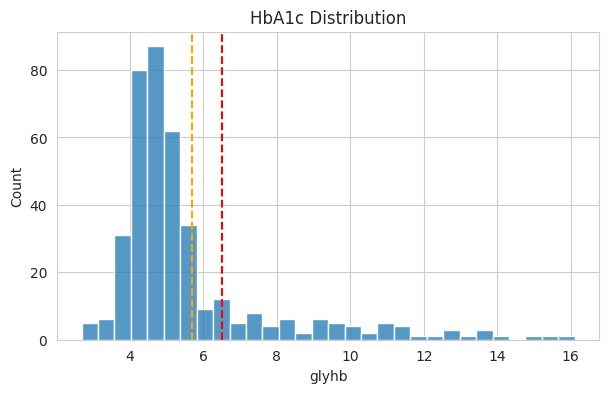

In [ ]:
plt.figure(figsize=(7,4))

sns.histplot(df["glyhb"].dropna(), bins=30)

plt.axvline(5.7,color="orange",linestyle="--")

plt.axvline(6.5,color="red",linestyle="--")

plt.title("HbA1c Distribution")

plt.show()

# 4 — Data Cleaning

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.dropna(subset=["glyhb"]).reset_index(drop=True)

# 5 — Target Variable Generation

In [ ]:
df["Diabetes"] = (df["glyhb"] >= 6.5).astype(int)

In [ ]:
print(df["Diabetes"].value_counts())

print(df["Diabetes"].value_counts(normalize=True))

Diabetes
0    325
1     65
Name: count, dtype: int64
Diabetes
0    0.833333
1    0.166667
Name: proportion, dtype: float64


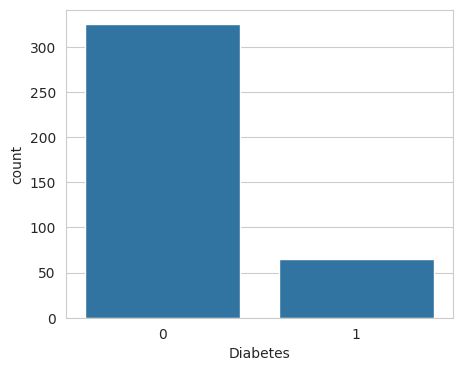

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x="Diabetes",data=df)

plt.show()

# 6 — Remove Data Leakage

In [ ]:
df = df.drop(columns=["glyhb"])

# 7 — Missing Value Treatment

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

imputer_num = SimpleImputer(strategy="median")

df[num_cols] = imputer_num.fit_transform(df[num_cols])

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

imputer_cat = SimpleImputer(strategy="most_frequent")

df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# 8 — Feature Engineerin

In [ ]:
df["height_m"] = df["height"]*0.0254

df["weight_kg"] = df["weight"]*0.453592

In [ ]:
df['bmi'] = df['weight_kg'] / (df['height_m'] ** 2)

df['waist_hip_ratio'] = df['waist'] / df['hip']

# 9 — Remove Unnecessary Features

In [ ]:
columns_to_remove = [

    "id",

    "bp.2s",

    "bp.2d",

    "location",

    "frame",

    "hdl",

    "hip",

    'waist',

    "height_m",

    "weight_kg",

    "weight",

    "height",

    "gender",
    "ratio"


]

df = df.drop(columns=columns_to_remove)

In [ ]:
df.columns

Index(['chol', 'stab.glu', 'age', 'bp.1s', 'bp.1d', 'time.ppn', 'Diabetes',
       'bmi', 'waist_hip_ratio'],
      dtype='object')

# 10 — Encoding

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(

    df,

    columns=cat_cols,

    drop_first=True,

    dtype=int

)

# 11 — Define Features

In [ ]:
X = df.drop("Diabetes",axis=1)

y = df["Diabetes"]

# 12 — Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

# 13 Handle Class Imbalance

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train,y_train = smote.fit_resample(

    X_train,

    y_train

)

# 14 — Train Gradient Boosting

In [ ]:
model = GradientBoostingClassifier(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    subsample=0.8,

    random_state=42

)

model.fit(

    X_train,

    y_train

)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42, subsample=0.8)

# 15 — Prediction

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

#16 — Evaluation

In [ ]:
print("Accuracy",accuracy_score(y_test,y_pred))

print("Precision",precision_score(y_test,y_pred))

print("Recall",recall_score(y_test,y_pred))

print("F1",f1_score(y_test,y_pred))

print("ROC AUC",roc_auc_score(y_test,y_prob))

Accuracy 0.9102564102564102
Precision 0.7142857142857143
Recall 0.7692307692307693
F1 0.7407407407407407
ROC AUC 0.9562130177514794


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.94      0.95        65
         1.0       0.71      0.77      0.74        13

    accuracy                           0.91        78
   macro avg       0.83      0.85      0.84        78
weighted avg       0.91      0.91      0.91        78



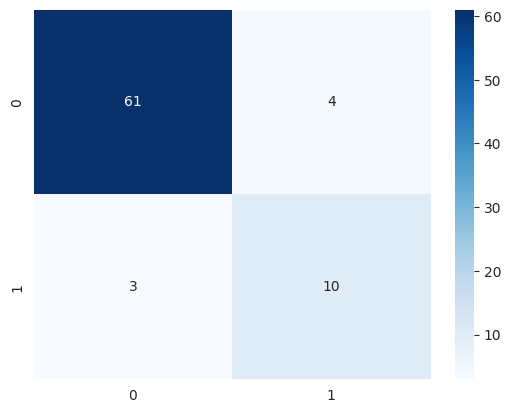

In [ ]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,

            annot=True,

            fmt="d",

            cmap="Blues")

plt.show()

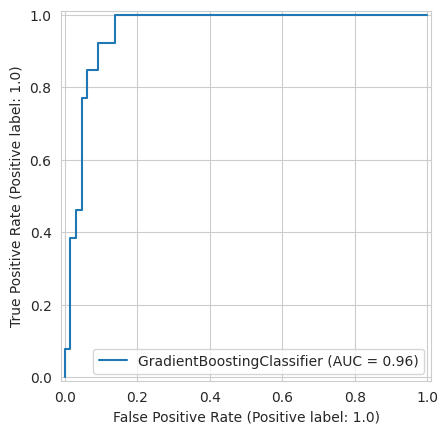

In [ ]:
RocCurveDisplay.from_estimator(

    model,

    X_test,

    y_test

)

plt.show()

# 17 — Cross Validation

In [ ]:
scores = cross_val_score(

    model,

    X,

    y,

    cv=5,

    scoring="roc_auc"

)

print(scores)

print(scores.mean())

[0.9739645  0.92781065 0.93372781 0.94201183 0.88639053]
0.9327810650887575


# 18 — Feature Importance

In [ ]:
importance = pd.Series(

    model.feature_importances_,

    index=X.columns

).sort_values(ascending=False)

print(importance)

stab.glu           0.637525
age                0.109352
bp.1s              0.054054
bp.1d              0.049246
chol               0.045361
bmi                0.042892
time.ppn           0.035359
waist_hip_ratio    0.026212
dtype: float64


# -- Test with new data

In [ ]:
import pandas as pd
import joblib

# ---- Load the trained deployable model ----
model = joblib.load("diabetes_model.pkl")
FEATURES = joblib.load("feature_names.pkl")

# ---- Helper: build the derived features (bmi, waist_hip_ratio) from raw measurements ----
def make_patient_row(chol, stab_glu, age, bp_1s, bp_1d, time_ppn,
                      height_in, weight_lb, waist, hip):
    height_m = height_in * 0.0254
    weight_kg = weight_lb * 0.453592
    bmi = weight_kg / (height_m ** 2)
    waist_hip_ratio = waist / hip
    return {
        "chol": chol,
        "stab.glu": stab_glu,
        "age": age,
        "bp.1s": bp_1s,
        "bp.1d": bp_1d,
        "time.ppn": time_ppn,
        "bmi": bmi,
        "waist_hip_ratio": waist_hip_ratio,
    }

def predict_patient(patient_dict, label="Patient"):
    row = pd.DataFrame([patient_dict])[FEATURES]
    prob = model.predict_proba(row)[0, 1]
    pred = model.predict(row)[0]
    status = "🔴 HIGH RISK — likely Diabetic" if pred == 1 else "🟢 LOW RISK — likely Non-Diabetic"
    print(f"--- {label} ---")
    print(row.to_string(index=False))
    print(f"Predicted class      : {'Diabetic (1)' if pred == 1 else 'Non-Diabetic (0)'}")
    print(f"Diabetes probability : {prob*100:.2f}%")
    print(f"Result                : {status}\n")
    return pred, prob

# TEST 1: A new patient you enter manually
new_patient_1 = make_patient_row(
    chol=240,
    stab_glu=210,
    age=58,
    bp_1s=150,
    bp_1d=95,
    time_ppn=300,
    height_in=65,
    weight_lb=210,
    waist=42,
    hip=44,
)
predict_patient(new_patient_1, label="New Patient #1")

#  TEST 2: A healthier-looking patient
new_patient_2 = make_patient_row(
    chol=180,
    stab_glu=85,
    age=30,
    bp_1s=115,
    bp_1d=75,
    time_ppn=180,
    height_in=68,
    weight_lb=150,
    waist=32,
    hip=38,
)
predict_patient(new_patient_2, label="New Patient #2")

batch_patients = pd.DataFrame([
    make_patient_row(220, 190, 55, 145, 90, 240, 64, 200, 40, 43),
    make_patient_row(175, 88,  28, 110, 70, 120, 67, 155, 31, 37),
    make_patient_row(260, 260, 62, 160, 100, 360, 62, 230, 45, 46),
])[FEATURES]

batch_patients["Predicted_Diabetes"] = model.predict(batch_patients)
batch_patients["Diabetes_Probability_%"] = (model.predict_proba(batch_patients)[:, 1] * 100).round(2)
batch_patients["Result"] = batch_patients["Predicted_Diabetes"].map(
    {1: "🔴 Diabetic", 0: "🟢 Non-Diabetic"}
)

print("=== Batch Prediction Results ===")
batch_patients

--- New Patient #1 ---
 chol  stab.glu  age  bp.1s  bp.1d  time.ppn       bmi  waist_hip_ratio
  240       210   58    150     95       300 34.945442         0.954545
Predicted class      : Diabetic (1)
Diabetes probability : 99.97%
Result                : 🔴 HIGH RISK — likely Diabetic

--- New Patient #2 ---
 chol  stab.glu  age  bp.1s  bp.1d  time.ppn       bmi  waist_hip_ratio
  180        85   30    115     75       180 22.807169         0.842105
Predicted class      : Non-Diabetic (0)
Diabetes probability : 0.03%
Result                : 🟢 LOW RISK — likely Non-Diabetic

=== Batch Prediction Results ===


,chol,stab.glu,age,bp.1s,bp.1d,time.ppn,bmi,waist_hip_ratio,Predicted_Diabetes,Diabetes_Probability_%,Result
0,220,190,55,145,90,240,34.329541,0.930233,1,99.940002,🔴 Diabetic
1,175,88,28,110,70,120,24.276163,0.837838,0,0.040000,🟢 Non-Diabetic
2,260,260,62,160,100,360,42.067084,0.978261,1,99.349998,🔴 Diabetic


# 19 Model comparision

In [ ]:
candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': model,
}

try:
    from xgboost import XGBClassifier
    candidates['XGBoost'] = XGBClassifier(eval_metric='logloss', random_state=42)
except ImportError:
    print('xgboost not installed - skipping (pip install xgboost --break-system-packages)')

try:
    from lightgbm import LGBMClassifier
    candidates['LightGBM'] = LGBMClassifier(random_state=42, verbose=-1)
except ImportError:
    print('lightgbm not installed - skipping (pip install lightgbm --break-system-packages)')

results = []
for name, clf in candidates.items():
    if name != 'Gradient Boosting':
        clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    prob = clf.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.923077,0.705882,0.923077,0.800000,0.969231
1,Random Forest,0.923077,0.733333,0.846154,0.785714,0.962130
2,Gradient Boosting,0.910256,0.714286,0.769231,0.740741,0.956213
3,LightGBM,0.871795,0.600000,0.692308,0.642857,0.946746
4,Logistic Regression,0.858974,0.555556,0.769231,0.645161,0.931361
5,Decision Tree,0.846154,0.526316,0.769231,0.625000,0.815385


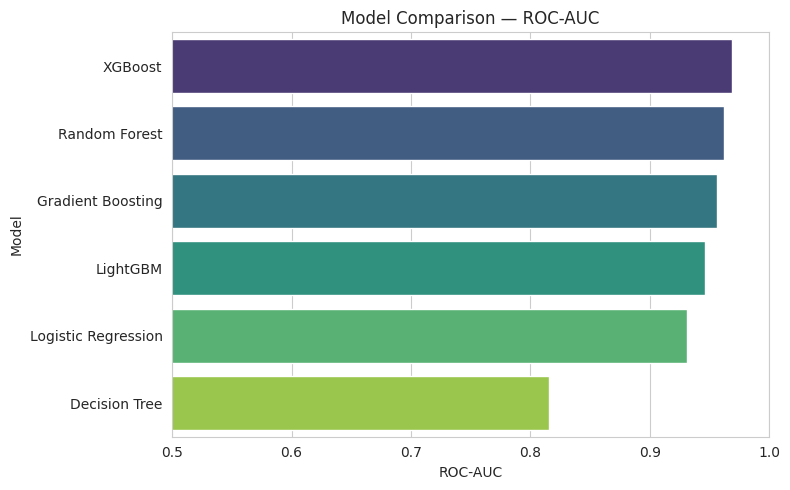

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='ROC-AUC', y='Model', palette='viridis')
plt.title('Model Comparison — ROC-AUC')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()
